--- T-test p-values (Whole Trajectory vs Feature) ---
Whole Traj. vs FiringRate: p = 4.9130e-48
Whole Traj. vs BurstFraction: p = 1.1489e-89
Whole Traj. vs ISI: p = 4.4918e-64
Whole Traj. vs Combined: p = 1.7095e-06

--- T-test p-values (Combined vs Individual Feature) ---
Combined vs FiringRate: p = 2.3158e-39
Combined vs BurstFraction: p = 1.4721e-84
Combined vs ISI: p = 5.2310e-58


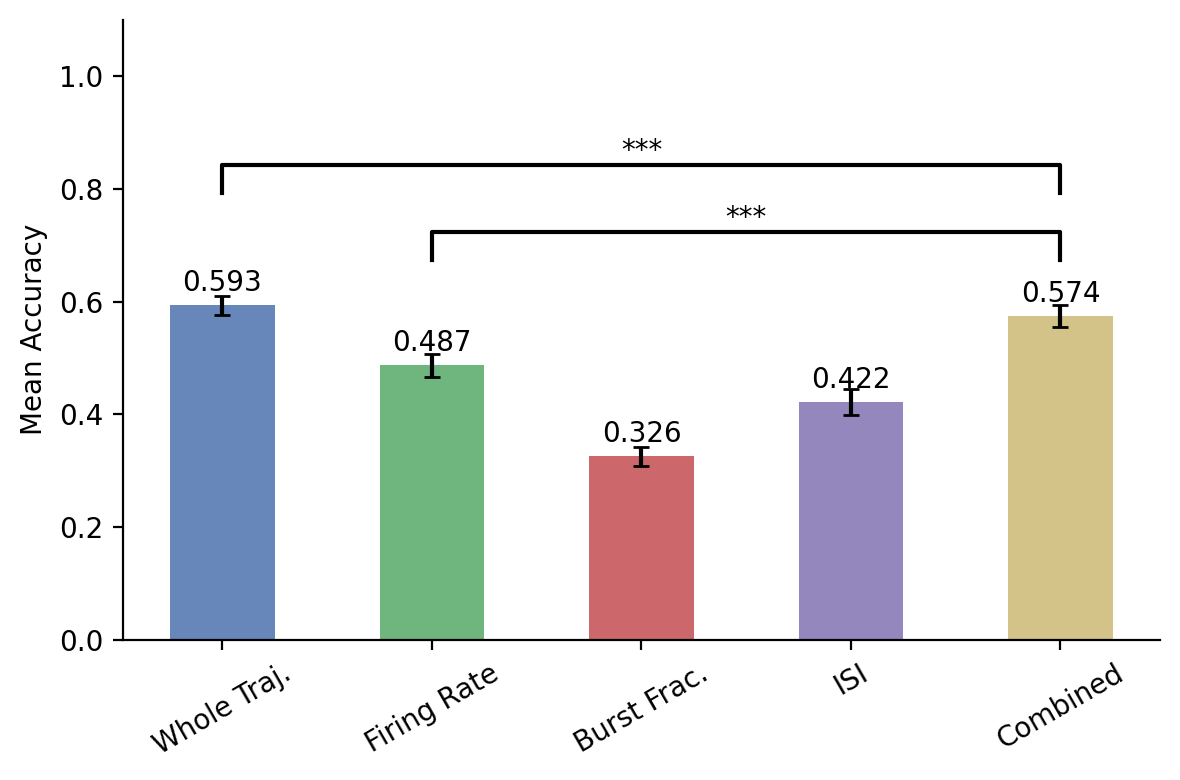

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os
import seaborn as sns

# --- Define Paths ---
save_dir_original = '/content/drive/MyDrive/Project/PlasticityDecoding/result'
save_dir_new = '/content/drive/MyDrive/Project/PlasticityDecoding/result_20260601'

# --- Load Data ---
# 1. Whole Trajectory SVM Result
# Note: The original file has shape (50, 6) where col 0 is overall accuracy.
svm_whole_traj = np.load(os.path.join(save_dir_original, 'svm_fixedrepresentation.npy'))
whole_traj_acc = svm_whole_traj[:, 0]

# 2. Handcrafted Features SVM Results (In-Distribution)
features = ['FiringRate', 'BurstFraction', 'ISI', 'Combined']
handcrafted_acc = {}

for feat in features:
    data = np.load(os.path.join(save_dir_new, f'svm_fixedrep_{feat}_in_dist.npy'))
    handcrafted_acc[feat] = data[:, 0] # Extract overall accuracy (col 0)

# --- Prepare Data for Plotting ---
labels = ['Whole Traj.', 'Firing Rate', 'Burst Frac.', 'ISI', 'Combined']
means = [
    np.mean(whole_traj_acc),
    np.mean(handcrafted_acc['FiringRate']),
    np.mean(handcrafted_acc['BurstFraction']),
    np.mean(handcrafted_acc['ISI']),
    np.mean(handcrafted_acc['Combined'])
]
stds = [
    np.std(whole_traj_acc),
    np.std(handcrafted_acc['FiringRate']),
    np.std(handcrafted_acc['BurstFraction']),
    np.std(handcrafted_acc['ISI']),
    np.std(handcrafted_acc['Combined'])
]

# --- Perform T-tests ---
# 1. Whole Trajectory vs others
t_stats_whole = {}
p_vals_whole = {}
for feat in features:
    t_stat, p_val = stats.ttest_ind(whole_traj_acc, handcrafted_acc[feat])
    t_stats_whole[feat] = p_val

# 2. Combined vs individual handcrafted features
t_stats_combined = {}
p_vals_combined = {}
for feat in ['FiringRate', 'BurstFraction', 'ISI']:
    t_stat, p_val = stats.ttest_ind(handcrafted_acc['Combined'], handcrafted_acc[feat])
    t_stats_combined[feat] = p_val

# --- Print Statistical Results ---
print("--- T-test p-values (Whole Trajectory vs Feature) ---")
for feat in features:
    print(f"Whole Traj. vs {feat}: p = {t_stats_whole[feat]:.4e}")

print("\n--- T-test p-values (Combined vs Individual Feature) ---")
for feat in ['FiringRate', 'BurstFraction', 'ISI']:
    print(f"Combined vs {feat}: p = {t_stats_combined[feat]:.4e}")


# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
bars = ax.bar(labels, means, yerr=stds, capsize=3, width=0.5, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'], alpha=0.85)

# Add significance markers (Optional: You can adjust this logic based on your preferred p-value threshold)
def add_significance_marker(ax, x1, x2, y, h, p_val):
    if p_val < 0.05:
        stars = '*' if p_val < 0.05 else ''
        stars = '**' if p_val < 0.001 else stars
        stars = '***' if p_val < 0.0001 else stars
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
        ax.text((x1+x2)*.5, y+h, stars, ha='center', va='bottom', color='black')

# Example of adding a few markers (adjust heights 'y' and 'h' as needed to avoid overlap)
# Whole vs Combined
add_significance_marker(ax, 0, 4, max(means[0], means[4]) + 0.2, 0.05, t_stats_whole['Combined'])
# Combined vs Firing Rate
add_significance_marker(ax, 1, 4, max(means[1], means[4]) + 0.1, 0.05, t_stats_combined['FiringRate'])


ax.set_ylabel('Mean Accuracy')
# ax.set_title('SVM Classification Accuracy: Whole Trajectory vs. Handcrafted Features')
ax.set_ylim(0, 1.1) # Assuming accuracy is between 0 and 1, add some headroom for error bars/markers

# Add text labels on bars
for bar in bars:
  height = bar.get_height()
  ax.annotate(f'{height:.3f}',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 3),  # 3 points vertical offset
      textcoords="offset points",
      ha='center', va='bottom')

plt.xticks(rotation=30)
plt.tight_layout()
sns.despine()
plt.show()

# Optional: Save the figure
# fig.savefig(os.path.join(save_dir_new, 'svm_feature_comparison.png'), dpi=300)

--- T-test p-values for TCNN (Base vs Broad Groups) ---
Base vs Group 1 (0.2, 0.3 -> 0.4): p = 8.8100e-14
Base vs Group 2 (0.2, 0.4 -> 0.3): p = 2.6920e-14
Base vs Group 3 (0.3, 0.4 -> 0.2): p = 2.3738e-11

--- T-test p-values for TTE (Base vs Broad Groups) ---
Base vs Group 1 (0.2, 0.3 -> 0.4): p = 8.1969e-13
Base vs Group 2 (0.2, 0.4 -> 0.3): p = 1.8534e-16
Base vs Group 3 (0.3, 0.4 -> 0.2): p = 9.5061e-21


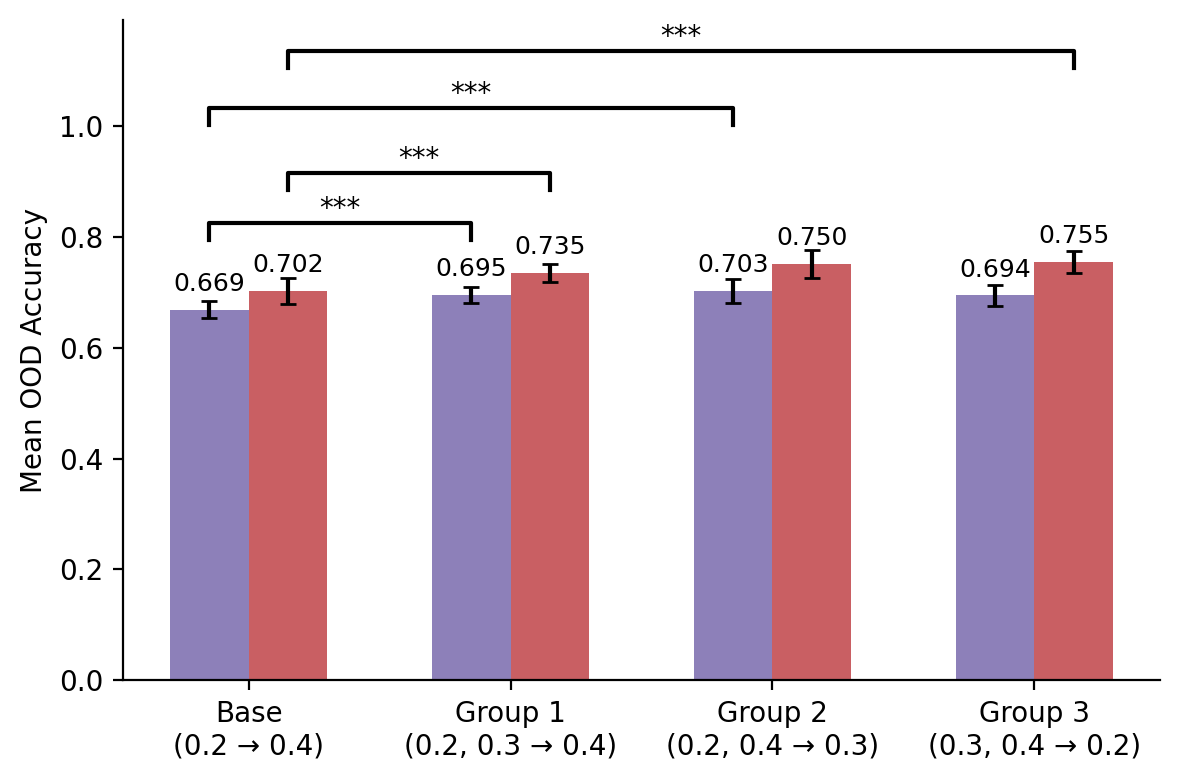

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os
import seaborn as sns

# --- Define Paths ---
save_dir_base = '/content/drive/MyDrive/Project/PlasticityDecoding/result'
save_dir_broad = '/content/drive/MyDrive/Project/PlasticityDecoding/result_20260601'

# --- Load Data ---
# Note: Adjust the column index [:, 0] if your overall OOD accuracy is stored at a different index (e.g., [:, 1])
# 1. Base OOD Results (Train 0.2 -> Predict 0.4)
tcnn_base_ood = np.load(os.path.join(save_dir_base, 'TCNN_fixedrepresentation1.npy'))[:, 1]
tte_base_ood = np.load(os.path.join(save_dir_base, 'TTE_fixedrepresentation1.npy'))[:, 1]

# 2. Broad OOD Results
# Assuming these contain the 12-element parsed matrices from the previous broad OOD script.
# We are extracting the Overall OOD Test Accuracy (index 1 if you used the parsed 12-element list from the previous script)
# Please update the filenames below if you saved them under different names!
idx_overall_out = 1 # Update to 0 if you saved the out-dist matrix separately

tcnn_broad_1 = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test1_out.npy'))[:, idx_overall_out] # Train 0.2+0.3 -> Predict 0.4
tcnn_broad_2 = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test2_out.npy'))[:, idx_overall_out] # Train 0.2+0.4 -> Predict 0.3
tcnn_broad_3 = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test3_out.npy'))[:, idx_overall_out] # Train 0.3+0.4 -> Predict 0.2

tte_broad_1 = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test1_out.npy'))[:, idx_overall_out]
tte_broad_2 = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test2_out.npy'))[:, idx_overall_out]
tte_broad_3 = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test3_out.npy'))[:, idx_overall_out]

# --- Prepare Data for Plotting ---
conditions = ['Base\n(0.2 \u2192 0.4)', 'Group 1\n(0.2, 0.3 \u2192 0.4)', 'Group 2\n(0.2, 0.4 \u2192 0.3)', 'Group 3\n(0.3, 0.4 \u2192 0.2)']

tcnn_means = [np.mean(tcnn_base_ood), np.mean(tcnn_broad_1), np.mean(tcnn_broad_2), np.mean(tcnn_broad_3)]
tcnn_stds = [np.std(tcnn_base_ood), np.std(tcnn_broad_1), np.std(tcnn_broad_2), np.std(tcnn_broad_3)]

tte_means = [np.mean(tte_base_ood), np.mean(tte_broad_1), np.mean(tte_broad_2), np.mean(tte_broad_3)]
tte_stds = [np.std(tte_base_ood), np.std(tte_broad_1), np.std(tte_broad_2), np.std(tte_broad_3)]

# --- Perform T-tests ---
print("--- T-test p-values for TCNN (Base vs Broad Groups) ---")
_, p_tcnn_g1 = stats.ttest_ind(tcnn_base_ood, tcnn_broad_1)
_, p_tcnn_g2 = stats.ttest_ind(tcnn_base_ood, tcnn_broad_2)
_, p_tcnn_g3 = stats.ttest_ind(tcnn_base_ood, tcnn_broad_3)
print(f"Base vs Group 1 (0.2, 0.3 -> 0.4): p = {p_tcnn_g1:.4e}")
print(f"Base vs Group 2 (0.2, 0.4 -> 0.3): p = {p_tcnn_g2:.4e}")
print(f"Base vs Group 3 (0.3, 0.4 -> 0.2): p = {p_tcnn_g3:.4e}")

print("\n--- T-test p-values for TTE (Base vs Broad Groups) ---")
_, p_tte_g1 = stats.ttest_ind(tte_base_ood, tte_broad_1)
_, p_tte_g2 = stats.ttest_ind(tte_base_ood, tte_broad_2)
_, p_tte_g3 = stats.ttest_ind(tte_base_ood, tte_broad_3)
print(f"Base vs Group 1 (0.2, 0.3 -> 0.4): p = {p_tte_g1:.4e}")
print(f"Base vs Group 2 (0.2, 0.4 -> 0.3): p = {p_tte_g2:.4e}")
print(f"Base vs Group 3 (0.3, 0.4 -> 0.2): p = {p_tte_g3:.4e}")


# --- Plotting ---
x = np.arange(len(conditions))  # the label locations
width = 0.3  # the width of the bars

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

# Plot grouped bars
bars1 = ax.bar(x - width/2, tcnn_means, width, yerr=tcnn_stds, capsize=3, label='TCNN', color='#8172B2', alpha=0.9)
bars2 = ax.bar(x + width/2, tte_means, width, yerr=tte_stds, capsize=3, label='TTE', color='#C44E52', alpha=0.9)

# Add Labels, Title, and Legend
ax.set_ylabel('Mean OOD Accuracy')
# ax.set_title('Out-of-Distribution Generalization: Base vs. Broad Training Data')
ax.set_xticks(x)
ax.set_xticklabels(conditions)
# ax.set_ylim(0, 1.1)
# ax.legend()

# Helper to attach text labels above bars
def autolabel(bars):
    """Attach a text label above each bar, displaying its height."""
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(bars1)
autolabel(bars2)

# Helper for Significance Brackets
def add_significance_bracket(ax, x1, x2, y, h, p_val):
    if p_val < 0.05:
        stars = '*' if p_val < 0.05 else ''
        stars = '**' if p_val < 0.001 else stars
        stars = '***' if p_val < 0.0001 else stars
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
        ax.text((x1+x2)*.5, y+h, stars, ha='center', va='bottom', color='black')

# Add significance brackets for Base vs Group 1 (Since both predict 0.4, this is the most direct comparison)
# TCNN (Base vs G1)
max_tcnn_1 = max(tcnn_means[0], tcnn_means[1]) + 0.1
add_significance_bracket(ax, x[0] - width/2, x[1] - width/2, max_tcnn_1, 0.03, p_tcnn_g1)

max_tcnn_2 = max(tcnn_means[0], tcnn_means[2]) + 0.3
add_significance_bracket(ax, x[0] - width/2, x[2] - width/2, max_tcnn_2, 0.03, p_tcnn_g2)

# TTE (Base vs G1)
max_tte_1 = max(tte_means[0], tte_means[1]) + 0.15
add_significance_bracket(ax, x[0] + width/2, x[1] + width/2, max_tte_1, 0.03, p_tte_g1)

max_tte_3 = max(tte_means[0], tte_means[3]) + 0.35
add_significance_bracket(ax, x[0] + width/2, x[3] + width/2, max_tte_3, 0.03, p_tte_g3)

sns.despine()
plt.tight_layout()
plt.show()

# Optional: Save the figure
# fig.savefig(os.path.join(save_dir_broad, 'OOD_broad_training_comparison.png'), dpi=300)

--- T-test p-values for OOD ACCURACY (Base vs Broad) ---
TCNN | Base vs Group 1 (0.2, 0.3 -> 0.4): p = 8.8100e-14
TTE  | Base vs Group 1 (0.2, 0.3 -> 0.4): p = 8.1969e-13

--- T-test p-values for ACCURACY DROP (Base vs Broad) ---
TCNN | Base Drop vs Group 1 Drop: p = 4.3881e-05
TCNN | Base Drop vs Group 2 Drop: p = 1.3066e-12
TCNN | Base Drop vs Group 3 Drop: p = 1.1161e-08

TTE  | Base Drop vs Group 1 Drop: p = 4.2668e-06
TTE  | Base Drop vs Group 2 Drop: p = 1.5172e-15
TTE  | Base Drop vs Group 3 Drop: p = 4.2933e-17



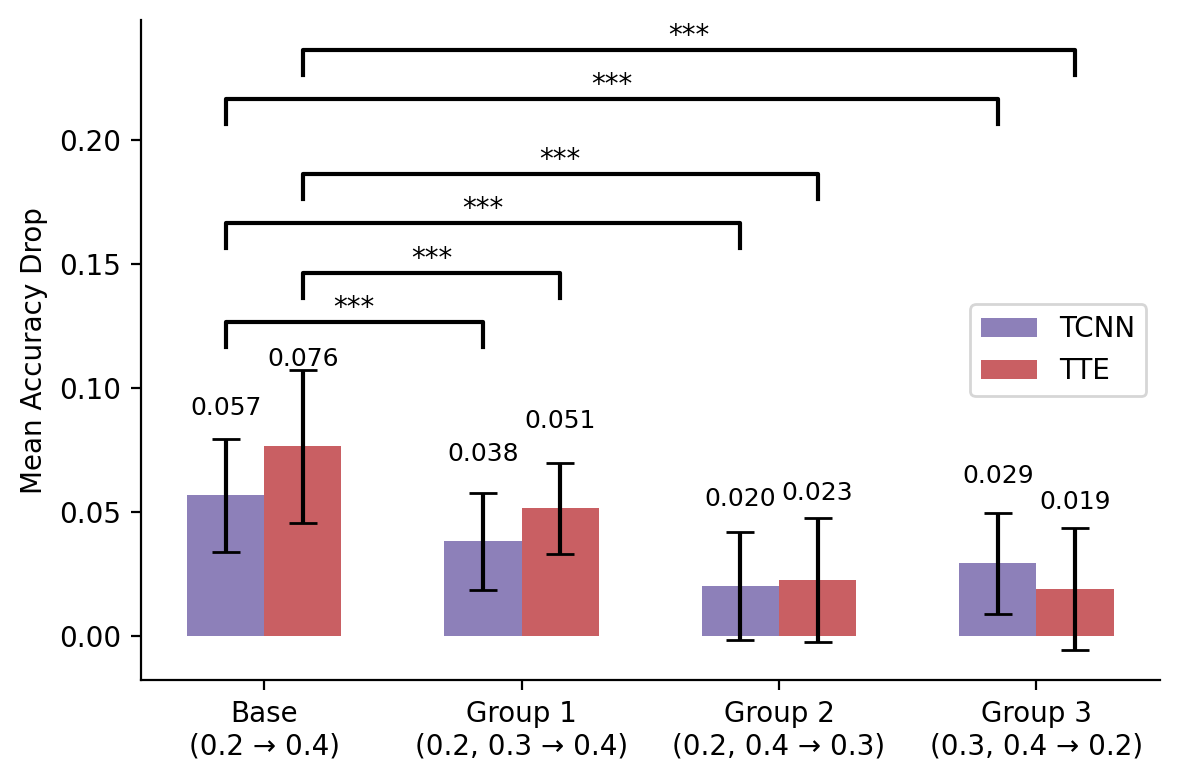

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

# --- Define Paths ---
save_dir_base = '/content/drive/MyDrive/Project/PlasticityDecoding/result'
save_dir_broad = '/content/drive/MyDrive/Project/PlasticityDecoding/result_20260601'

# --- Load Data: Absolute Accuracies ---
# 1. Base Results (Train 0.2 -> Predict 0.4)
# Index 0 is typically the overall accuracy in your base arrays
tcnn_base_in = np.load(os.path.join(save_dir_base, 'TCNN_fixedrepresentation.npy'))[:, 1]
tte_base_in = np.load(os.path.join(save_dir_base, 'TTE_fixedrepresentation.npy'))[:, 1]
tcnn_base_ood = np.load(os.path.join(save_dir_base, 'TCNN_fixedrepresentation1.npy'))[:, 1]
tte_base_ood = np.load(os.path.join(save_dir_base, 'TTE_fixedrepresentation1.npy'))[:, 1]

# 2. Broad OOD Results (Using index 1 for Overall Test Accuracy based on our previous 12-element parsing)
idx_overall_test = 1

tcnn_broad_1_in = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test1_in.npy'))[:, idx_overall_test]
tcnn_broad_2_in = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test2_in.npy'))[:, idx_overall_test]
tcnn_broad_3_in = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test3_in.npy'))[:, idx_overall_test]

tcnn_broad_1_out = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test1_out.npy'))[:, idx_overall_test]
tcnn_broad_2_out = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test2_out.npy'))[:, idx_overall_test]
tcnn_broad_3_out = np.load(os.path.join(save_dir_broad, 'TCNN_broad_OOD_Test3_out.npy'))[:, idx_overall_test]

tte_broad_1_in = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test1_in.npy'))[:, idx_overall_test]
tte_broad_2_in = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test2_in.npy'))[:, idx_overall_test]
tte_broad_3_in = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test3_in.npy'))[:, idx_overall_test]

tte_broad_1_out = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test1_out.npy'))[:, idx_overall_test]
tte_broad_2_out = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test2_out.npy'))[:, idx_overall_test]
tte_broad_3_out = np.load(os.path.join(save_dir_broad, 'TTE_broad_OOD_Test3_out.npy'))[:, idx_overall_test]


# --- Calculate Accuracy Drops (In-Dist - Out-Dist) ---
tcnn_base_drop = tcnn_base_in - tcnn_base_ood
tcnn_drop_1 = tcnn_broad_1_in - tcnn_broad_1_out
tcnn_drop_2 = tcnn_broad_2_in - tcnn_broad_2_out
tcnn_drop_3 = tcnn_broad_3_in - tcnn_broad_3_out

tte_base_drop = tte_base_in - tte_base_ood
tte_drop_1 = tte_broad_1_in - tte_broad_1_out
tte_drop_2 = tte_broad_2_in - tte_broad_2_out
tte_drop_3 = tte_broad_3_in - tte_broad_3_out


# --- Prepare Data for Plotting ---
conditions = ['Base\n(0.2 \u2192 0.4)', 'Group 1\n(0.2, 0.3 \u2192 0.4)', 'Group 2\n(0.2, 0.4 \u2192 0.3)', 'Group 3\n(0.3, 0.4 \u2192 0.2)']

# Arrays for Figure 1 (Absolute OOD)
tcnn_ood_means = [np.mean(tcnn_base_ood), np.mean(tcnn_broad_1_out), np.mean(tcnn_broad_2_out), np.mean(tcnn_broad_3_out)]
tcnn_ood_stds = [np.std(tcnn_base_ood), np.std(tcnn_broad_1_out), np.std(tcnn_broad_2_out), np.std(tcnn_broad_3_out)]

tte_ood_means = [np.mean(tte_base_ood), np.mean(tte_broad_1_out), np.mean(tte_broad_2_out), np.mean(tte_broad_3_out)]
tte_ood_stds = [np.std(tte_base_ood), np.std(tte_broad_1_out), np.std(tte_broad_2_out), np.std(tte_broad_3_out)]

# Arrays for Figure 2 (Accuracy Drops)
tcnn_drop_means = [np.mean(tcnn_base_drop), np.mean(tcnn_drop_1), np.mean(tcnn_drop_2), np.mean(tcnn_drop_3)]
tcnn_drop_stds = [np.std(tcnn_base_drop), np.std(tcnn_drop_1), np.std(tcnn_drop_2), np.std(tcnn_drop_3)]

tte_drop_means = [np.mean(tte_base_drop), np.mean(tte_drop_1), np.mean(tte_drop_2), np.mean(tte_drop_3)]
tte_drop_stds = [np.std(tte_base_drop), np.std(tte_drop_1), np.std(tte_drop_2), np.std(tte_drop_3)]


# --- Perform T-tests ---
print("======================================================")
print("--- T-test p-values for OOD ACCURACY (Base vs Broad) ---")
_, p_tcnn_acc_g1 = stats.ttest_ind(tcnn_base_ood, tcnn_broad_1_out)
_, p_tte_acc_g1 = stats.ttest_ind(tte_base_ood, tte_broad_1_out)
print(f"TCNN | Base vs Group 1 (0.2, 0.3 -> 0.4): p = {p_tcnn_acc_g1:.4e}")
print(f"TTE  | Base vs Group 1 (0.2, 0.3 -> 0.4): p = {p_tte_acc_g1:.4e}")

print("\n======================================================")
print("--- T-test p-values for ACCURACY DROP (Base vs Broad) ---")
_, p_tcnn_drop_g1 = stats.ttest_ind(tcnn_base_drop, tcnn_drop_1)
_, p_tcnn_drop_g2 = stats.ttest_ind(tcnn_base_drop, tcnn_drop_2)
_, p_tcnn_drop_g3 = stats.ttest_ind(tcnn_base_drop, tcnn_drop_3)
print(f"TCNN | Base Drop vs Group 1 Drop: p = {p_tcnn_drop_g1:.4e}")
print(f"TCNN | Base Drop vs Group 2 Drop: p = {p_tcnn_drop_g2:.4e}")
print(f"TCNN | Base Drop vs Group 3 Drop: p = {p_tcnn_drop_g3:.4e}")

_, p_tte_drop_g1 = stats.ttest_ind(tte_base_drop, tte_drop_1)
_, p_tte_drop_g2 = stats.ttest_ind(tte_base_drop, tte_drop_2)
_, p_tte_drop_g3 = stats.ttest_ind(tte_base_drop, tte_drop_3)
print(f"\nTTE  | Base Drop vs Group 1 Drop: p = {p_tte_drop_g1:.4e}")
print(f"TTE  | Base Drop vs Group 2 Drop: p = {p_tte_drop_g2:.4e}")
print(f"TTE  | Base Drop vs Group 3 Drop: p = {p_tte_drop_g3:.4e}")
print("======================================================\n")


# --- Plotting ---
x = np.arange(len(conditions))  # the label locations
width = 0.3  # the width of the bars

def autolabel(ax, bars, is_drop=False):
    """Attach a text label above each bar, displaying its height."""
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 27),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

def add_significance_bracket(ax, x1, x2, y, h, p_val):
    if p_val < 0.05:
        stars = '*' if p_val < 0.05 else ''
        stars = '**' if p_val < 0.001 else stars
        stars = '***' if p_val < 0.0001 else stars
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
        ax.text((x1+x2)*.5, y+h, stars, ha='center', va='bottom', color='black')


# ==========================================
# FIGURE 2: Accuracy Drop (In-Dist - Out-Dist)
# ==========================================
fig2, ax2 = plt.subplots(figsize=(6, 4), dpi=200)

bars1_drop = ax2.bar(x - width/2, tcnn_drop_means, width, yerr=tcnn_drop_stds, capsize=5, label='TCNN', color='#8172B2', alpha=0.9)
bars2_drop = ax2.bar(x + width/2, tte_drop_means, width, yerr=tte_drop_stds, capsize=5, label='TTE', color='#C44E52', alpha=0.9)

ax2.set_ylabel('Mean Accuracy Drop')
# ax2.set_title('Performance Degradation: Base vs. Broad Training Data')
ax2.set_xticks(x)
ax2.set_xticklabels(conditions)
# ax2.set_ylim(0, 0.2) # Dynamic Y limit based on drops
ax2.legend(loc='best')

autolabel(ax2, bars1_drop, is_drop=True)
autolabel(ax2, bars2_drop, is_drop=True)

# Brackets for Accuracy Drop (Base vs Group 1)
max_tcnn_drop = max(tcnn_drop_means[0], tcnn_drop_means[1]) + 0.06
add_significance_bracket(ax2, x[0] - width/2, x[1] - width/2, max_tcnn_drop, 0.01, p_tcnn_drop_g1)

max_tcnn_drop = max(tcnn_drop_means[0], tcnn_drop_means[2]) + 0.1
add_significance_bracket(ax2, x[0] - width/2, x[2] - width/2, max_tcnn_drop, 0.01, p_tcnn_drop_g2)

max_tcnn_drop = max(tcnn_drop_means[0], tcnn_drop_means[3]) + 0.15
add_significance_bracket(ax2, x[0] - width/2, x[3] - width/2, max_tcnn_drop, 0.01, p_tcnn_drop_g3)

max_tte_drop = max(tte_drop_means[0], tte_drop_means[1]) + 0.06
add_significance_bracket(ax2, x[0] + width/2, x[1] + width/2, max_tte_drop, 0.01, p_tte_drop_g1)

max_tte_drop = max(tte_drop_means[0], tte_drop_means[2]) + 0.1
add_significance_bracket(ax2, x[0] + width/2, x[2] + width/2, max_tte_drop, 0.01, p_tte_drop_g2)

max_tte_drop = max(tte_drop_means[0], tte_drop_means[3]) + 0.15
add_significance_bracket(ax2, x[0] + width/2, x[3] + width/2, max_tte_drop, 0.01, p_tte_drop_g3)

sns.despine()
fig2.tight_layout()
plt.show()

# Optional: Save the figures
# fig1.savefig(os.path.join(save_dir_broad, 'OOD_broad_accuracy_comparison.png'), dpi=300)
# fig2.savefig(os.path.join(save_dir_broad, 'OOD_broad_drop_comparison.png'), dpi=300)

In [ ]:
!dir '/content/drive/MyDrive/Project/PlasticityDecoding/result_20260601'

svm_fixedrep_BurstFraction_in_dist_class_0.npy
svm_fixedrep_BurstFraction_in_dist_class_1.npy
svm_fixedrep_BurstFraction_in_dist_class_2.npy
svm_fixedrep_BurstFraction_in_dist_class_3.npy
svm_fixedrep_BurstFraction_in_dist_class_4.npy
svm_fixedrep_BurstFraction_in_dist.npy
svm_fixedrep_BurstFraction_out_dist_class_0.npy
svm_fixedrep_BurstFraction_out_dist_class_1.npy
svm_fixedrep_BurstFraction_out_dist_class_2.npy
svm_fixedrep_BurstFraction_out_dist_class_3.npy
svm_fixedrep_BurstFraction_out_dist_class_4.npy
svm_fixedrep_BurstFraction_out_dist.npy
svm_fixedrep_Combined_in_dist_class_0.npy
svm_fixedrep_Combined_in_dist_class_1.npy
svm_fixedrep_Combined_in_dist_class_2.npy
svm_fixedrep_Combined_in_dist_class_3.npy
svm_fixedrep_Combined_in_dist_class_4.npy
svm_fixedrep_Combined_in_dist.npy
svm_fixedrep_Combined_out_dist_class_0.npy
svm_fixedrep_Combined_out_dist_class_1.npy
svm_fixedrep_Combined_out_dist_class_2.npy
svm_fixedrep_Combined_out_dist_class_3.npy
svm_fixedrep_Combined_out_dist

In [ ]:
import numpy as np
import json
import os

# --- Define Paths ---
save_dir = '/content/drive/MyDrive/Project/PlasticityDecoding/result_20260601'
json_output_path = os.path.join(save_dir, 'aggregated_results.json')

# --- List of all files to process ---
file_list = [
    "svm_fixedrep_BurstFraction_in_dist_class_0.npy",
    "svm_fixedrep_BurstFraction_in_dist_class_1.npy",
    "svm_fixedrep_BurstFraction_in_dist_class_2.npy",
    "svm_fixedrep_BurstFraction_in_dist_class_3.npy",
    "svm_fixedrep_BurstFraction_in_dist_class_4.npy",
    "svm_fixedrep_BurstFraction_in_dist.npy",
    "svm_fixedrep_BurstFraction_out_dist_class_0.npy",
    "svm_fixedrep_BurstFraction_out_dist_class_1.npy",
    "svm_fixedrep_BurstFraction_out_dist_class_2.npy",
    "svm_fixedrep_BurstFraction_out_dist_class_3.npy",
    "svm_fixedrep_BurstFraction_out_dist_class_4.npy",
    "svm_fixedrep_BurstFraction_out_dist.npy",
    "svm_fixedrep_Combined_in_dist_class_0.npy",
    "svm_fixedrep_Combined_in_dist_class_1.npy",
    "svm_fixedrep_Combined_in_dist_class_2.npy",
    "svm_fixedrep_Combined_in_dist_class_3.npy",
    "svm_fixedrep_Combined_in_dist_class_4.npy",
    "svm_fixedrep_Combined_in_dist.npy",
    "svm_fixedrep_Combined_out_dist_class_0.npy",
    "svm_fixedrep_Combined_out_dist_class_1.npy",
    "svm_fixedrep_Combined_out_dist_class_2.npy",
    "svm_fixedrep_Combined_out_dist_class_3.npy",
    "svm_fixedrep_Combined_out_dist_class_4.npy",
    "svm_fixedrep_Combined_out_dist.npy",
    "svm_fixedrep_FiringRate_in_dist_class_0.npy",
    "svm_fixedrep_FiringRate_in_dist_class_1.npy",
    "svm_fixedrep_FiringRate_in_dist_class_2.npy",
    "svm_fixedrep_FiringRate_in_dist_class_3.npy",
    "svm_fixedrep_FiringRate_in_dist_class_4.npy",
    "svm_fixedrep_FiringRate_in_dist.npy",
    "svm_fixedrep_FiringRate_out_dist_class_0.npy",
    "svm_fixedrep_FiringRate_out_dist_class_1.npy",
    "svm_fixedrep_FiringRate_out_dist_class_2.npy",
    "svm_fixedrep_FiringRate_out_dist_class_3.npy",
    "svm_fixedrep_FiringRate_out_dist_class_4.npy",
    "svm_fixedrep_FiringRate_out_dist.npy",
    "svm_fixedrep_ISI_in_dist_class_0.npy",
    "svm_fixedrep_ISI_in_dist_class_1.npy",
    "svm_fixedrep_ISI_in_dist_class_2.npy",
    "svm_fixedrep_ISI_in_dist_class_3.npy",
    "svm_fixedrep_ISI_in_dist_class_4.npy",
    "svm_fixedrep_ISI_in_dist.npy",
    "svm_fixedrep_ISI_out_dist_class_0.npy",
    "svm_fixedrep_ISI_out_dist_class_1.npy",
    "svm_fixedrep_ISI_out_dist_class_2.npy",
    "svm_fixedrep_ISI_out_dist_class_3.npy",
    "svm_fixedrep_ISI_out_dist_class_4.npy",
    "svm_fixedrep_ISI_out_dist.npy",
    "TCNN_broad_OOD_Test1_in.npy",
    "TCNN_broad_OOD_Test1_out.npy",
    "TCNN_broad_OOD_Test2_in.npy",
    "TCNN_broad_OOD_Test2_out.npy",
    "TCNN_broad_OOD_Test3_in.npy",
    "TCNN_broad_OOD_Test3_out.npy",
    "TCNN_endtoend_no_NC_confusion.npy",
    "TCNN_endtoend_no_NC_confusion_out_dist.npy",
    "TCNN_endtoend_no_NC.npy",
    "TCNN_endtoend_no_NC_out_dist.npy",
    "TCNN_OOD_time_Merged.npy",
    "TCNN_OOD_time_SPK.npy",
    "TTE_broad_OOD_Test1_in.npy",
    "TTE_broad_OOD_Test1_out.npy",
    "TTE_broad_OOD_Test2_in.npy",
    "TTE_broad_OOD_Test2_out.npy",
    "TTE_broad_OOD_Test3_in.npy",
    "TTE_broad_OOD_Test3_out.npy",
    "TTE_endtoend_no_NC_confusion.npy",
    "TTE_endtoend_no_NC_confusion_out_dist.npy",
    "TTE_endtoend_no_NC.npy",
    "TTE_endtoend_no_NC_out_dist.npy",
    "TTE_OOD_time_Merged.npy",
    "TTE_OOD_time_SPK.npy"
]

results_dict = {}

# --- Process Each File ---
for filename in file_list:
    filepath = os.path.join(save_dir, filename)

    if not os.path.exists(filepath):
        print(f"Warning: File not found, skipping -> {filename}")
        continue

    try:
        data = np.load(filepath)

        # Confusion matrices are single aggregated 2D arrays, averaging them across axis 0 doesn't make sense
        if "confusion" in filename:
            results_dict[filename] = {
                "raw_matrix": data.tolist()
            }
        else:
            # For standard metric matrices (iterations, metrics), compute mean and std across iterations (axis 0)
            mean_val = np.mean(data, axis=0)
            std_val = np.std(data, axis=0)

            # Convert NumPy arrays to lists for JSON serialization
            results_dict[filename] = {
                "mean": np.round(mean_val, 4).tolist(),
                "std": np.round(std_val, 4).tolist()
            }

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --- Save to JSON ---
try:
    with open(json_output_path, 'w') as json_file:
        json.dump(results_dict, json_file, indent=4)
    print(f"\nSuccess! All results successfully aggregated and saved to:\n{json_output_path}")
except Exception as e:
    print(f"Failed to write JSON file: {e}")


Success! All results successfully aggregated and saved to:
/content/drive/MyDrive/Project/PlasticityDecoding/result_20260601/aggregated_results.json


In [ ]:
import json
import os

def get_mean_std(data, key, idx):
    """Safely extracts mean and std, formats them for LaTeX."""
    try:
        m = data[key]['mean'][idx]
        s = data[key]['std'][idx]
        return f"${m:.3f} \\pm {s:.3f}$"
    except (KeyError, IndexError):
        return "N/A"

def main():
    # Define paths
    json_path = '/content/drive/MyDrive/Project/PlasticityDecoding/result_20260601/aggregated_results.json'
    out_path = '/content/drive/MyDrive/Project/PlasticityDecoding/result_20260601/manuscript_tables.tex'

    # Fallback to local directory if the full drive path isn't found
    if not os.path.exists(json_path):
        json_path = 'aggregated_results.json'
        out_path = 'manuscript_tables.tex'

    print(f"Loading data from: {json_path}")
    with open(json_path, 'r') as f:
        data = json.load(f)

    tex = []

    # --- LaTeX Preamble ---
    tex.append(r"\documentclass{article}")
    tex.append(r"\usepackage{booktabs}")
    tex.append(r"\usepackage{geometry}")
    tex.append(r"\usepackage{graphicx}")
    tex.append(r"\geometry{a4paper, margin=1in}")
    tex.append(r"\begin{document}")
    tex.append(r"")

    # ==========================================
    # Table 1: SVM Handcrafted Features
    # ==========================================
    tex.append(r"\begin{table}[ht]")
    tex.append(r"\centering")
    tex.append(r"\caption{SVM Classification Accuracy using Handcrafted Features}")
    tex.append(r"\resizebox{\textwidth}{!}{")
    tex.append(r"\begin{tabular}{llcccccc}")
    tex.append(r"\toprule")
    tex.append(r"\textbf{Feature} & \textbf{Test Dist.} & \textbf{Overall} & \textbf{STDP} & \textbf{BDP} & \textbf{BPTT1} & \textbf{BPTT2} & \textbf{NC} \\")
    tex.append(r"\midrule")
    for feat in ['FiringRate', 'BurstFraction', 'ISI', 'Combined']:
        for dist in ['in', 'out']:
            key = f"svm_fixedrep_{feat}_{dist}_dist.npy"
            dist_str = "In-Dist" if dist == 'in' else "Out-Dist"
            row = f"{feat} & {dist_str} "
            # Indices: 0:Overall, 1:Class0, ..., 5:Class4
            for i in range(6):
                row += f"& {get_mean_std(data, key, i)} "
            row += r"\\"
            tex.append(row)
        tex.append(r"\midrule")
    tex.append(r"\bottomrule")
    tex.append(r"\end{tabular}")
    tex.append(r"}")
    tex.append(r"\end{table}")
    tex.append(r"")

    # ==========================================
    # Table 2: Task-Oriented Without NC (3 Classes)
    # ==========================================
    tex.append(r"\begin{table}[ht]")
    tex.append(r"\centering")
    tex.append(r"\caption{Task-Oriented Classification without Negative Control (NC)}")
    tex.append(r"\begin{tabular}{llcccc}")
    tex.append(r"\toprule")
    tex.append(r"\textbf{Model} & \textbf{Test Dist.} & \textbf{Overall} & \textbf{STDP} & \textbf{BPTT1} & \textbf{BPTT2} \\")
    tex.append(r"\midrule")
    for model in ['TCNN', 'TTE']:
        for dist in ['in', 'out']:
            key = f"{model}_endtoend_no_NC.npy" if dist == 'in' else f"{model}_endtoend_no_NC_out_dist.npy"
            dist_str = "In-Dist" if dist == 'in' else "Out-Dist"
            row = f"{model} & {dist_str} "
            # Test Indices: 1:Overall, 3:STDP, 5:BPTT1, 7:BPTT2
            for i in [1, 3, 5, 7]:
                row += f"& {get_mean_std(data, key, i)} "
            row += r"\\"
            tex.append(row)
    tex.append(r"\bottomrule")
    tex.append(r"\end{tabular}")
    tex.append(r"\end{table}")
    tex.append(r"")

    # ==========================================
    # Table 3: Temporal Generalization (Half-to-Half)
    # ==========================================
    tex.append(r"\begin{table}[ht]")
    tex.append(r"\centering")
    tex.append(r"\caption{Temporal Generalization (Trained on first half, tested on second half)}")
    tex.append(r"\resizebox{\textwidth}{!}{")
    tex.append(r"\begin{tabular}{llcccccc}")
    tex.append(r"\toprule")
    tex.append(r"\textbf{Model} & \textbf{Dataset} & \textbf{Overall} & \textbf{STDP} & \textbf{BDP} & \textbf{BPTT1} & \textbf{BPTT2} & \textbf{NC} \\")
    tex.append(r"\midrule")
    for model in ['TCNN', 'TTE']:
        for ds in ['SPK', 'Merged']:
            key = f"{model}_OOD_time_{ds}.npy"
            row = f"{model} & {ds} "
            # Test Indices: 1:Overall, 3:C0, 5:C1, 7:C2, 9:C3, 11:C4
            for i in [1, 3, 5, 7, 9, 11]:
                row += f"& {get_mean_std(data, key, i)} "
            row += r"\\"
            tex.append(row)
        tex.append(r"\midrule")
    tex.append(r"\bottomrule")
    tex.append(r"\end{tabular}")
    tex.append(r"}")
    tex.append(r"\end{table}")
    tex.append(r"")

    # ==========================================
    # Table 4: Broad OOD Generalization (3 Groups)
    # ==========================================
    tex.append(r"\begin{table}[ht]")
    tex.append(r"\centering")
    tex.append(r"\caption{Broad OOD Generalization (Training on two distributions, testing on a third)}")
    tex.append(r"\resizebox{\textwidth}{!}{")
    tex.append(r"\begin{tabular}{llcccccc}")
    tex.append(r"\toprule")
    tex.append(r"\textbf{Model} & \textbf{OOD Task} & \textbf{Overall} & \textbf{STDP} & \textbf{BDP} & \textbf{BPTT1} & \textbf{BPTT2} & \textbf{NC} \\")
    tex.append(r"\midrule")
    task_names = {
        'Test1': r'0.2, 0.3 $\rightarrow$ 0.4',
        'Test2': r'0.2, 0.4 $\rightarrow$ 0.3',
        'Test3': r'0.3, 0.4 $\rightarrow$ 0.2'
    }
    for model in ['TCNN', 'TTE']:
        for t in ['Test1', 'Test2', 'Test3']:
            key = f"{model}_broad_OOD_{t}_out.npy"
            row = f"{model} & {task_names[t]} "
            # Test Indices: 1:Overall, 3:C0, 5:C1, 7:C2, 9:C3, 11:C4
            for i in [1, 3, 5, 7, 9, 11]:
                row += f"& {get_mean_std(data, key, i)} "
            row += r"\\"
            tex.append(row)
        if model == 'TCNN':
            tex.append(r"\midrule")
    tex.append(r"\bottomrule")
    tex.append(r"\end{tabular}")
    tex.append(r"}")
    tex.append(r"\end{table}")
    tex.append(r"")

    tex.append(r"\end{document}")

    # --- Write to file ---
    with open(out_path, 'w') as f:
        f.write('\n'.join(tex))

    print(f"\nSuccess! LaTeX tables generated and saved to: {out_path}")
    print("You can open this file in any text editor, or upload it directly to Overleaf to compile!")

if __name__ == '__main__':
    main()

Loading data from: /content/drive/MyDrive/Project/PlasticityDecoding/result_20260601/aggregated_results.json

Success! LaTeX tables generated and saved to: /content/drive/MyDrive/Project/PlasticityDecoding/result_20260601/manuscript_tables.tex
You can open this file in any text editor, or upload it directly to Overleaf to compile!
